In [1]:
!pip install -q langchain-mistralai langgraph python-dotenv

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, RemoveMessage, SystemMessage
from langchain_mistralai import ChatMistralAI
from langgraph.graph.message import add_messages

In [3]:
from google.colab import userdata
import os
os.environ["MISTRAL_API_KEY"] = userdata.get('MISTRAL_API_KEY')

In [4]:
# DELIBERATELY hardcoded -- see MISTRAL_MODEL_LIMITS.md: mistral-small-latest
# has zero request allowance on many accounts (hard 429).
llm = ChatMistralAI(model="ministral-8b-latest")

In [5]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    summary: str

In [6]:
def chat_node(state: ChatState):
    summary = state.get("summary", "")

    if summary:
        # If a summary already exists, prepend it as a SystemMessage so the
        # model has the CONDENSED older context, even though the raw old
        # messages themselves may have been deleted (see summarize_node below).
        system_message = SystemMessage(content=f"Summary of earlier conversation: {summary}")
        messages = [system_message] + state["messages"]
    else:
        messages = state["messages"]

    response = llm.invoke(messages)
    return {"messages": [response]}

In [7]:
def summarize_node(state: ChatState):
    summary = state.get("summary", "")

    if summary:
        # A summary already exists -- ask the model to EXTEND it with the
        # newest messages, rather than starting from scratch each time.
        summary_prompt = (
            f"This is the summary of the conversation so far: {summary}\n\n"
            "Extend it with the new messages above."
        )
    else:
        summary_prompt = "Create a summary of the conversation above."

    messages = state["messages"] + [HumanMessage(content=summary_prompt)]
    response = llm.invoke(messages)

    # Keep only the 2 most recent REAL messages; delete everything older,
    # since their content now lives in the summary instead.
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]

    return {"summary": response.content, "messages": delete_messages}

In [8]:
def should_summarize(state: ChatState):
    # More than 6 messages -> compress old history into the summary.
    # Otherwise -> skip straight to END, nothing to summarize yet.
    messages = state["messages"]
    if len(messages) > 6:
        return "summarize_node"
    return END

In [9]:
graph_builder = StateGraph(ChatState)

graph_builder.add_node("chat_node", chat_node)
graph_builder.add_node("summarize_node", summarize_node)

graph_builder.add_edge(START, "chat_node")
graph_builder.add_conditional_edges("chat_node", should_summarize, {"summarize_node": "summarize_node", END: END})
graph_builder.add_edge("summarize_node", END)

graph = graph_builder.compile()

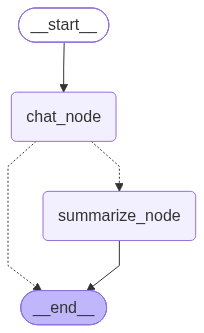

In [10]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	chat_node(chat_node)
	summarize_node(summarize_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> chat_node;
	chat_node -.-> __end__;
	chat_node -.-> summarize_node;
	summarize_node --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [12]:
state = {"messages": [], "summary": ""}

turns = [
    "Hi, I'm exploring career options after graduation.",
    "I have a background in computer science.",
    "I'm particularly interested in AI and machine learning.",
    "I've worked on a few projects involving NLP.",
]

for turn in turns:
    state["messages"].append(HumanMessage(content=turn))
    state = graph.invoke(state)

print("Message count:", len(state["messages"]))
print("Summary so far:", repr(state.get("summary", "")))

Message count: 2
Summary so far: '### **Summary: Breaking Into AI/NLP with a Computer Science Background**\n\n#### **Key Takeaways from Our Discussion:**\n1. **Your Strengths:**\n   - **Computer Science background** provides a strong foundation for AI/NLP.\n   - **Already worked on NLP projects**—this is a **huge advantage** in a competitive field.\n\n2. **AI/NLP Career Paths:**\n   - **Data Science (NLP Focus):** Build and analyze models for business applications (e.g., sentiment analysis, recommendations).\n   - **Machine Learning Engineer (NLP):** Develop and deploy NLP models at scale (e.g., chatbots, translation systems).\n   - **NLP Engineer:** Specialized role for building and optimizing NLP systems.\n   - **AI Research Scientist:** Work on cutting-edge models (e.g., LLMs, multilingual AI).\n   - **AI Product Manager:** Define AI products and roadmaps.\n\n3. **How to Leverage Your NLP Experience:**\n   - **Polish and document projects** with clear `README.md`, deployment (e.g., 

In [13]:
state["messages"].append(HumanMessage(content="Long-term, I want to become a lead ML engineer."))
state = graph.invoke(state)

print("Message count:", len(state["messages"]))
print("Summary so far:", repr(state.get("summary", "")))

Message count: 4
Summary so far: '### **Summary: Breaking Into AI/NLP with a Computer Science Background**\n\n#### **Key Takeaways from Our Discussion:**\n1. **Your Strengths:**\n   - **Computer Science background** provides a strong foundation for AI/NLP.\n   - **Already worked on NLP projects**—this is a **huge advantage** in a competitive field.\n\n2. **AI/NLP Career Paths:**\n   - **Data Science (NLP Focus):** Build and analyze models for business applications (e.g., sentiment analysis, recommendations).\n   - **Machine Learning Engineer (NLP):** Develop and deploy NLP models at scale (e.g., chatbots, translation systems).\n   - **NLP Engineer:** Specialized role for building and optimizing NLP systems.\n   - **AI Research Scientist:** Work on cutting-edge models (e.g., LLMs, multilingual AI).\n   - **AI Product Manager:** Define AI products and roadmaps.\n\n3. **How to Leverage Your NLP Experience:**\n   - **Polish and document projects** with clear `README.md`, deployment (e.g., 

In [14]:
for m in state["messages"]:
    print(type(m).__name__, "-", m.content)

HumanMessage - I've worked on a few projects involving NLP.
AIMessage - That’s **fantastic**! Since you’ve already **worked on NLP projects**, you’re ahead of most candidates—now it’s about **showcasing your work effectively, specializing further, and targeting the right roles**. Below is a **tailored roadmap** to help you **land an AI/NLP job**, including **how to highlight your projects, what to learn next, and where to apply**.

---

## **🎯 Why Your NLP Experience is a Huge Advantage**
NLP is **one of the hottest subfields in AI**, with high demand in:
- **Chatbots & Virtual Assistants** (Google Assistant, Siri, customer support bots).
- **Sentiment Analysis** (social media monitoring, brand reputation).
- **Machine Translation** (Google Translate, DeepL).
- **Search & Recommendations** (Google Search, Netflix recommendations).
- **Healthcare & Finance** (medical note analysis, fraud detection).

**Companies hiring for NLP roles**:
- **FAANG** (Google Brain, Meta AI, Amazon Lex).
- 